# Week 2 and 3 Deliverables

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

sold = pd.read_csv('csv/sold.csv', low_memory=False)
listings = pd.read_csv('csv/listings.csv', low_memory=False)

print(f"Sold shape: {sold.shape}")
print(f"Listings shape: {listings.shape}")

Sold shape: (430464, 82)
Listings shape: (591263, 84)


In [30]:
print("=== SOLD ===")
print(f"Rows: {sold.shape[0]}, Columns: {sold.shape[1]}")
print("\nColumn dtypes:")
print(sold.dtypes)

print("\n=== LISTINGS ===")
print(f"Rows: {listings.shape[0]}, Columns: {listings.shape[1]}")
print("\nColumn dtypes:")
print(listings.dtypes)

=== SOLD ===
Rows: 430464, Columns: 82

Column dtypes:
BuyerAgentAOR                    object
ListAgentAOR                     object
Flooring                         object
ViewYN                           object
WaterfrontYN                     object
                                 ...   
MiddleOrJuniorSchoolDistrict    float64
OriginatingSystemName            object
OriginatingSystemSubName         object
BuyerAgencyCompensationType      object
BuyerAgencyCompensation         float64
Length: 82, dtype: object

=== LISTINGS ===
Rows: 591263, Columns: 84

Column dtypes:
OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
                                 ...   
BuyerOfficeName.1                object
AssociationFee                  float64
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1  

In [31]:
print("Sold property types:")
print(sold['PropertyType'].value_counts())

print("\nListings property types:")
print(listings['PropertyType'].value_counts())

# Already filtered to Residential from Week 1 but confirming
print(f"\nSold unique property types: {sold['PropertyType'].unique()}")
print(f"Listings unique property types: {listings['PropertyType'].unique()}")

Sold property types:
PropertyType
Residential    430464
Name: count, dtype: int64

Listings property types:
PropertyType
Residential    591263
Name: count, dtype: int64

Sold unique property types: ['Residential']
Listings unique property types: ['Residential']


In [32]:
def missing_report(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'missing_count': missing, 'missing_pct': pct})
    report = report[report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    
    print(f"\n=== {name} — Missing Value Report ===")
    print(report.to_string())
    
    flagged = report[report['missing_pct'] > 90]
    print(f"\nColumns with >90% missing ({len(flagged)}):")
    print(flagged.to_string())
    
    return report

sold_missing = missing_report(sold, 'SOLD')
listings_missing = missing_report(listings, 'LISTINGS')


=== SOLD — Missing Value Report ===
                              missing_count  missing_pct
BusinessType                         430464       100.00
MiddleOrJuniorSchoolDistrict         430464       100.00
TaxAnnualAmount                      430464       100.00
TaxYear                              430464       100.00
ElementarySchoolDistrict             430464       100.00
AboveGradeFinishedArea               430464       100.00
CoveredSpaces                        430464       100.00
FireplacesTotal                      430464       100.00
WaterfrontYN                         430193        99.94
BelowGradeFinishedArea               427938        99.41
BasementYN                           422025        98.04
LotSizeDimensions                    409565        95.15
BuilderName                          409391        95.10
BuildingAreaTotal                    400292        92.99
CoBuyerAgentFirstName                391183        90.87
BuyerAgencyCompensationType          384328        

In [33]:
# Identify columns to drop
sold_drop = sold_missing[sold_missing['missing_pct'] > 90].index.tolist()
listings_drop = listings_missing[listings_missing['missing_pct'] > 90].index.tolist()

print(f"Dropping from sold: {sold_drop}")
print(f"Dropping from listings: {listings_drop}")

sold = sold.drop(columns=sold_drop)
listings = listings.drop(columns=listings_drop)

print(f"\nSold shape after dropping: {sold.shape}")
print(f"Listings shape after dropping: {listings.shape}")

Dropping from sold: ['BusinessType', 'MiddleOrJuniorSchoolDistrict', 'TaxAnnualAmount', 'TaxYear', 'ElementarySchoolDistrict', 'AboveGradeFinishedArea', 'CoveredSpaces', 'FireplacesTotal', 'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'LotSizeDimensions', 'BuilderName', 'BuildingAreaTotal', 'CoBuyerAgentFirstName']
Dropping from listings: ['TaxYear', 'CoveredSpaces', 'MiddleOrJuniorSchoolDistrict', 'BusinessType', 'TaxAnnualAmount', 'ElementarySchoolDistrict', 'AboveGradeFinishedArea', 'FireplacesTotal', 'BelowGradeFinishedArea', 'CoBuyerAgentFirstName', 'BuilderName', 'LotSizeDimensions', 'BuildingAreaTotal']

Sold shape after dropping: (430464, 67)
Listings shape after dropping: (591263, 71)


In [34]:
numeric_cols = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea',
                'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger',
                'DaysOnMarket', 'YearBuilt']

# Only use cols that exist in sold
numeric_cols_sold = [c for c in numeric_cols if c in sold.columns]

print("=== Numeric Distribution Summary (SOLD) ===")
summary = sold[numeric_cols_sold].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(summary.to_string())

=== Numeric Distribution Summary (SOLD) ===
         ClosePrice     ListPrice  OriginalListPrice    LivingArea  LotSizeAcres  BedroomsTotal  BathroomsTotalInteger   DaysOnMarket      YearBuilt
count  4.304620e+05  4.304640e+05       4.296750e+05  4.302190e+05  3.968060e+05  430452.000000          430394.000000  430464.000000  430082.000000
mean   1.193104e+06  1.141736e+06       1.226555e+06  1.904058e+03  6.400186e+01       3.203207               2.536666      37.333614    1978.601792
std    6.173986e+06  1.358076e+06       6.686592e+06  2.596744e+04  1.568719e+04       1.066818               1.132667      53.668934      26.292978
min    0.000000e+00  5.250000e+02       0.000000e+00  0.000000e+00  0.000000e+00       0.000000               0.000000    -288.000000    1776.000000
10%    4.150000e+05  4.190000e+05       4.250000e+05  9.840000e+02  6.200000e-02       2.000000               1.000000       4.000000    1947.000000
25%    5.750000e+05  5.780000e+05       5.850000e+05  1.248000

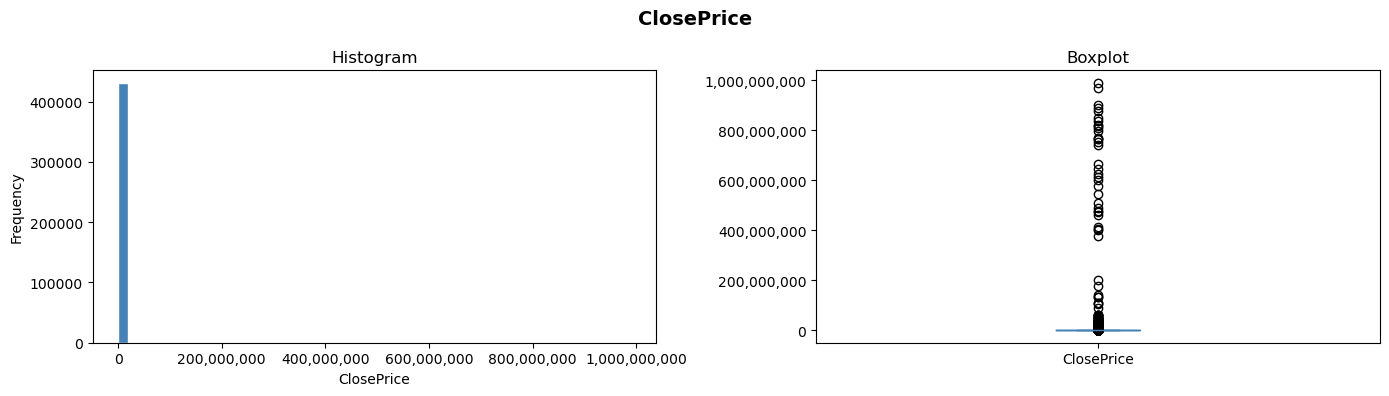

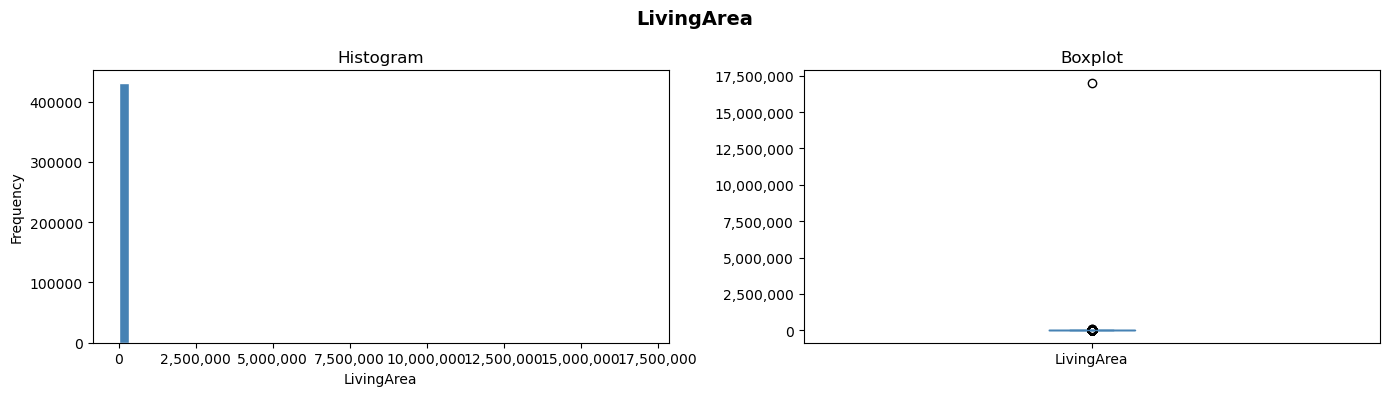

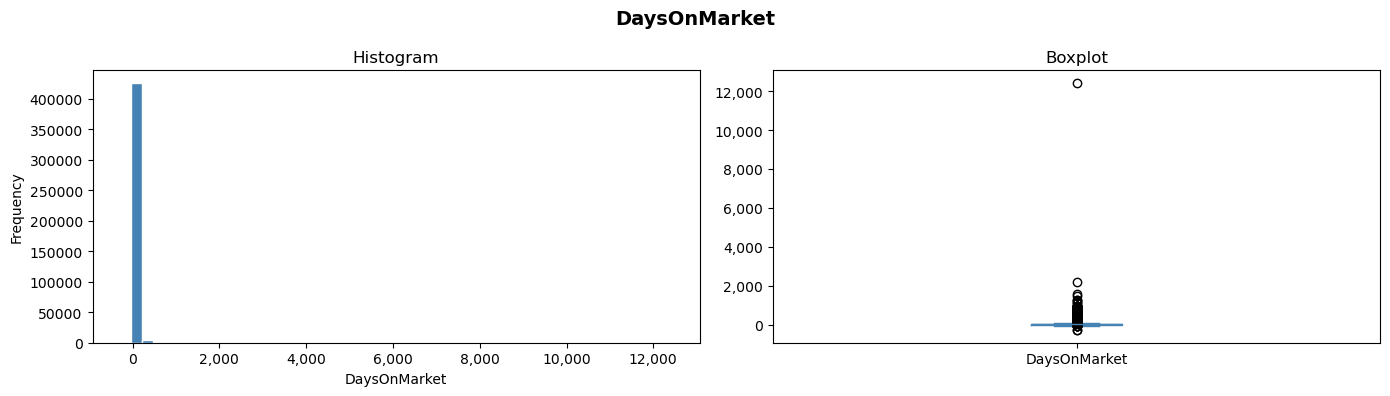

In [35]:
plot_cols = ['ClosePrice', 'LivingArea', 'DaysOnMarket']

for col in plot_cols:
    if col not in sold.columns:
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(col, fontsize=14, fontweight='bold')
    
    # Histogram
    sold[col].dropna().plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Histogram')
    axes[0].set_xlabel(col)
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    
    # Boxplot
    sold[[col]].dropna().plot(kind='box', ax=axes[1], color='steelblue')
    axes[1].set_title('Boxplot')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    
    plt.tight_layout()
    plt.show()

In [36]:
# Median and average close price
print("=== Close Price Stats ===")
print(f"Median: ${sold['ClosePrice'].median():,.0f}")
print(f"Mean:   ${sold['ClosePrice'].mean():,.0f}")

# Days on market distribution
print("\n=== Days on Market ===")
print(sold['DaysOnMarket'].describe())

# Sold above vs below list price
sold['above_list'] = sold['ClosePrice'] > sold['ListPrice']
pct_above = sold['above_list'].mean() * 100
print(f"\n=== Sold Above vs Below List Price ===")
print(f"Above list: {pct_above:.1f}%")
print(f"Below list: {100 - pct_above:.1f}%")

# Date consistency check
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'])
sold['ListingContractDate'] = pd.to_datetime(sold['ListingContractDate'])
date_issues = sold[sold['CloseDate'] < sold['ListingContractDate']]
print(f"\n=== Date Consistency Issues ===")
print(f"Records where CloseDate < ListingContractDate: {len(date_issues)}")

# Top counties by median close price
print("\n=== Top 10 Counties by Median Close Price ===")
county_prices = sold.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False)
print(county_prices.head(10).apply(lambda x: f"${x:,.0f}"))

=== Close Price Stats ===
Median: $825,000
Mean:   $1,193,104

=== Days on Market ===
count    430464.000000
mean         37.333614
std          53.668934
min        -288.000000
25%           8.000000
50%          18.000000
75%          48.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

=== Sold Above vs Below List Price ===
Above list: 40.1%
Below list: 59.9%

=== Date Consistency Issues ===
Records where CloseDate < ListingContractDate: 65

=== Top 10 Counties by Median Close Price ===
CountyOrParish
Del Norte        $2,485,000
Other County     $2,462,500
San Mateo        $1,700,000
Santa Clara      $1,600,000
San Francisco    $1,199,950
Santa Cruz       $1,199,444
Orange           $1,180,000
Marin            $1,172,500
Alameda          $1,140,000
Alpine           $1,100,000
Name: ClosePrice, dtype: object


In [37]:
# Fetch FRED mortgage rate data
mortgage_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(mortgage_url, parse_dates=['observation_date'])
mortgage.columns = ['date', 'rate_30yr_fixed']

# Resample to monthly average
mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)

print("Mortgage rate sample:")
print(mortgage_monthly.tail(5))

# Create year_month keys on MLS datasets
sold['year_month'] = pd.to_datetime(sold['CloseDate']).dt.to_period('M')
listings['year_month'] = pd.to_datetime(listings['ListingContractDate']).dt.to_period('M')

# Merge
sold_with_rates = sold.merge(mortgage_monthly, on='year_month', how='left')
listings_with_rates = listings.merge(mortgage_monthly, on='year_month', how='left')

# Validate
print(f"\nNull rates in sold after merge: {sold_with_rates['rate_30yr_fixed'].isnull().sum()}")
print(f"Null rates in listings after merge: {listings_with_rates['rate_30yr_fixed'].isnull().sum()}")

# Preview
print("\nSold with rates preview:")
print(sold_with_rates[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())

Mortgage rate sample:
    year_month  rate_30yr_fixed
658    2026-02           6.0475
659    2026-03           6.1775
660    2026-04           6.3320
661    2026-05           6.4425
662    2026-06           6.4900

Null rates in sold after merge: 0
Null rates in listings after merge: 0

Sold with rates preview:
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-26    2024-01    240000.0           6.6425
1 2024-01-05    2024-01    815000.0           6.6425
2 2024-01-05    2024-01    810000.0           6.6425
3 2024-01-30    2024-01    858000.0           6.6425
4 2024-01-29    2024-01   1890500.0           6.6425


In [ ]:
# sold_with_rates.to_csv('csv/sold_enriched.csv', index=False)
# listings_with_rates.to_csv('csv/listings_enriched.csv', index=False)

print(f"Saved sold_enriched.csv — {len(sold_with_rates)} rows")
print(f"Saved listings_enriched.csv — {len(listings_with_rates)} rows")

Saved sold_enriched.csv — 430464 rows
Saved listings_enriched.csv — 591263 rows
